<a href="https://colab.research.google.com/github/mahmudul2220/DMML/blob/main/colon_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!pip install split-folders -q

import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [24]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/colon/"
print(os.listdir(dataset_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['processed', 'models', 'With colon cancer', 'without colon cancer']


In [25]:
output_folder = "/content/drive/MyDrive/colon_split/"
IMG_SIZE = 224
BATCH_SIZE = 16

print(os.listdir(output_folder))

['train', 'val', 'test']


In [7]:
for cls in ['With colon cancer', 'without colon cancer']:
    path = os.path.join(dataset_path, cls)
    print(cls, "→", len(os.listdir(path)), "images")

With colon cancer → 5000 images
without colon cancer → 5000 images


In [8]:
clean_input = "/content/drive/MyDrive/colon_clean_input/"
os.makedirs(clean_input, exist_ok=True)

for cls in ['With colon cancer', 'without colon cancer']:
    src = os.path.join(dataset_path, cls)
    dst = os.path.join(clean_input, cls)
    if not os.path.exists(dst):
        shutil.copytree(src, dst)

print(os.listdir(clean_input))

['without colon cancer', 'With colon cancer']


Do not need run


In [25]:
output_folder = "/content/drive/MyDrive/colon_split/"

splitfolders.ratio(
    clean_input,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15),
    group_prefix=None
)

print(os.listdir(output_folder))

Copying files: 10000 files [06:59, 23.86 files/s]

['train', 'val', 'test']


10,000 image process

In [26]:
IMG_SIZE = 224
BATCH_SIZE = 16

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def preprocess_split(split_name):
    src_base = os.path.join(output_folder, split_name)
    for cls in os.listdir(src_base):
        cls_path = os.path.join(src_base, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = apply_clahe(img)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                cv2.imwrite(img_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            except Exception as e:
                print(f"Error: {img_path} -> {e}")
    print(f"{split_name} preprocessing done ✅")

for split in ["train", "val", "test"]:
    preprocess_split(split)

train preprocessing done ✅
val preprocessing done ✅
test preprocessing done ✅


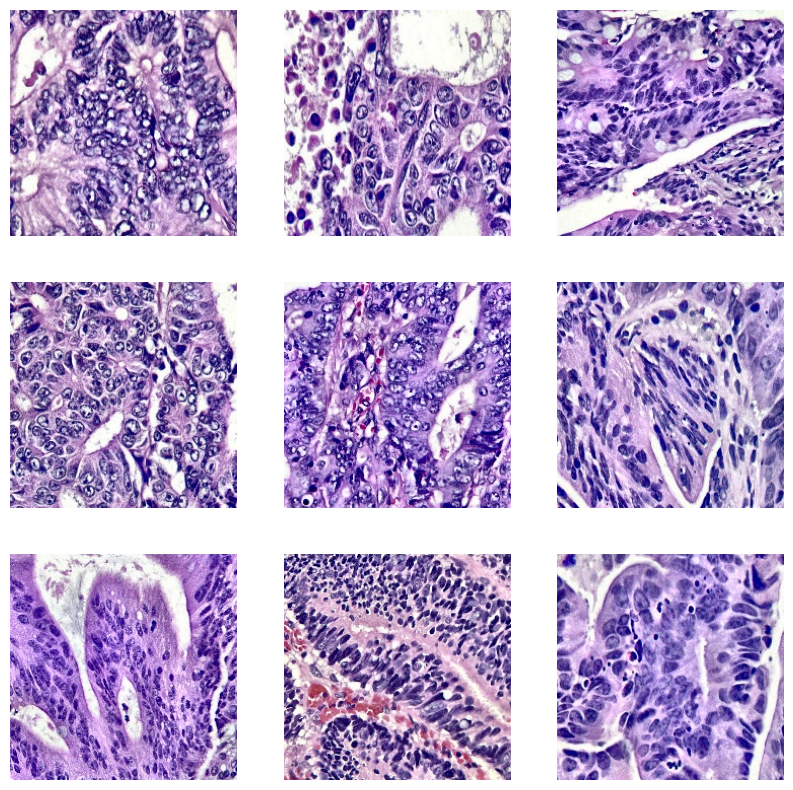

In [27]:
sample_path = os.path.join(output_folder, "train", "With colon cancer")
sample_imgs = os.listdir(sample_path)[:9]

plt.figure(figsize=(10, 10))
for i, img_name in enumerate(sample_imgs):
    img = cv2.imread(os.path.join(sample_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [ ]:
Data generator

In [26]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_generator = val_test_datagen.flow_from_directory(
    os.path.join(output_folder, "val"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(output_folder, "test"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
{'With colon cancer': 0, 'without colon cancer': 1}


Hybrid Model (Custom CNN + VGG16)

In [27]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Concatenate

def build_hybrid_model():
    input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ---------- Branch 1: Custom CNN ----------
    x1 = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    x1 = BatchNormalization()(x1)
    x1 = MaxPooling2D((2, 2))(x1)

    x1 = Conv2D(64, (3, 3), activation='relu', padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = MaxPooling2D((2, 2))(x1)

    x1 = Conv2D(128, (3, 3), activation='relu', padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = MaxPooling2D((2, 2))(x1)

    x1 = GlobalAveragePooling2D(name="custom_cnn_pool")(x1)

    # ---------- Branch 2: Pretrained VGG16 ----------
    vgg_base = VGG16(weights='imagenet', include_top=False, input_tensor=input_layer)
    vgg_base.trainable = False   # ফ্রিজ রাখা হচ্ছে, নাহলে overfit করবে
    x2 = GlobalAveragePooling2D(name="vgg_pool")(vgg_base.output)

    # ---------- Combine দুটো branch ----------
    combined = Concatenate(name="feature_fusion")([x1, x2])
    x = Dense(256, activation='relu')(combined)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(2, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output, name="Hybrid_CNN_VGG16")
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

hybrid_model = build_hybrid_model()
hybrid_model.summary()

Model: "Hybrid_CNN_VGG16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_3[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_3[

 Total params: 15,006,082 (57.24 MB)

 Trainable params: 290,946 (1.11 MB)

 Non-trainable params: 14,715,136 (56.13 MB)

In [28]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/colon/models/best_hybrid_model.h5',
                     save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history = hybrid_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8119 - loss: 0.3862

438/438 ━━━━━━━━━━━━━━━━━━━━ 1395s 3s/step - accuracy: 0.8973 - loss: 0.2440 - val_accuracy: 0.9827 - val_loss: 0.0946 - learning_rate: 1.0000e-04
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 140s 320ms/step - accuracy: 0.9769 - loss: 0.0700 - val_accuracy: 0.9720 - val_loss: 0.0720 - learning_rate: 1.0000e-04
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.9891 - loss: 0.0370

438/438 ━━━━━━━━━━━━━━━━━━━━ 138s 316ms/step - accuracy: 0.9876 - loss: 0.0361 - val_accuracy: 0.9907 - val_loss: 0.0317 - learning_rate: 1.0000e-04
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.9894 - loss: 0.0350

438/438 ━━━━━━━━━━━━━━━━━━━━ 139s 317ms/step - accuracy: 0.9911 - loss: 0.0276 - val_accuracy: 0.9953 - val_loss: 0.0138 - learning_rate: 1.0000e-04
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 148s 338ms/step - accuracy: 0.9934 - loss: 0.0202 - val_accuracy: 0.9953 - val_loss: 0.0124 - learning_rate: 1.0000e-04
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.9940 - loss: 0.0176

438/438 ━━━━━━━━━━━━━━━━━━━━ 138s 314ms/step - accuracy: 0.9953 - loss: 0.0145 - val_accuracy: 0.9987 - val_loss: 0.0099 - learning_rate: 1.0000e-04
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 137s 313ms/step - accuracy: 0.9941 - loss: 0.0150 - val_accuracy: 0.9920 - val_loss: 0.0260 - learning_rate: 1.0000e-04
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 136s 311ms/step - accuracy: 0.9957 - loss: 0.0133 - val_accuracy: 0.8787 - val_loss: 0.3809 - learning_rate: 1.0000e-04
Epoch 9/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 136s 310ms/step - accuracy: 0.9981 - loss: 0.0079 - val_accuracy: 0.9987 - val_loss: 0.0031 - learning_rate: 1.0000e-04
Epoch 10/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 137s 312ms/step - accuracy: 0.9967 - loss: 0.0098 - val_accuracy: 0.9960 - val_loss: 0.0104 - learning_rate: 1.0000e-04
Epoch 11/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 134s 306ms/step - accuracy: 0.9974 - loss: 0.0074 - val_accuracy: 0.9987 - val_loss: 0.0038 - learning_rate: 1.0000e-04
Epoch 12/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 135s 309

In [31]:
hybrid_model.save('/content/drive/MyDrive/colon/models/best_hybrid_model.h5')
print("Model saved to Drive ✅")

Model saved to Drive ✅


In [32]:
test_generator.reset()
test_loss, test_acc = hybrid_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 571s 6s/step - accuracy: 0.9987 - loss: 0.0044
Test Accuracy: 0.9987, Test Loss: 0.0044


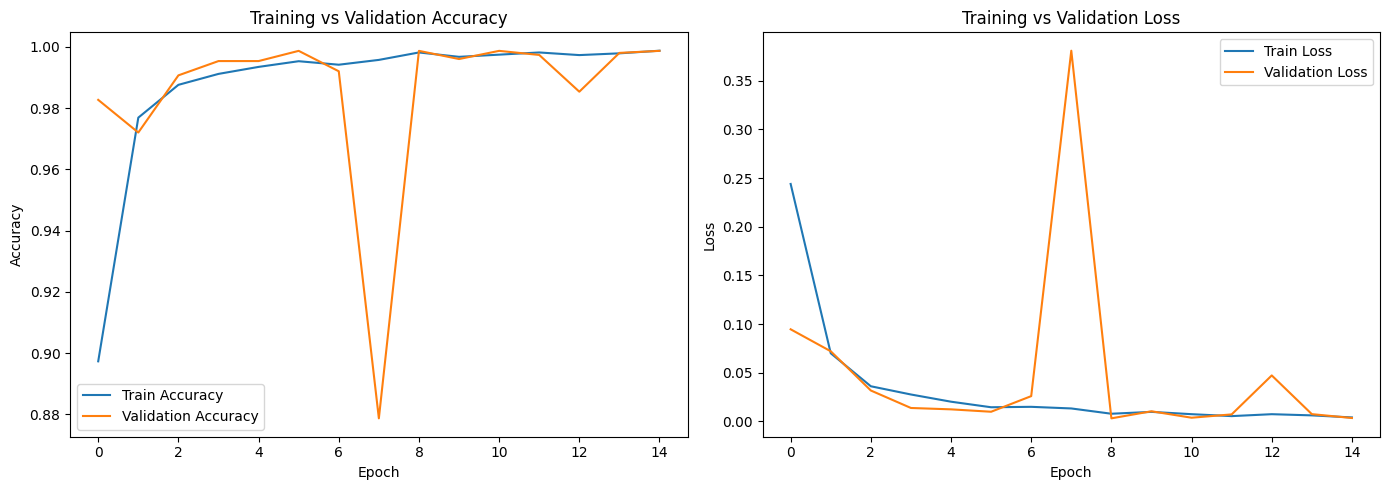

In [33]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/colon/models/hybrid_training_curve.png', dpi=300)
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.9987 - loss: 0.0044
Test Accuracy: 0.9987, Test Loss: 0.0044
94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step
                      precision    recall  f1-score   support

   With colon cancer       1.00      1.00      1.00       750
without colon cancer       1.00      1.00      1.00       750

            accuracy                           1.00      1500
           macro avg       1.00      1.00      1.00      1500
        weighted avg       1.00      1.00      1.00      1500



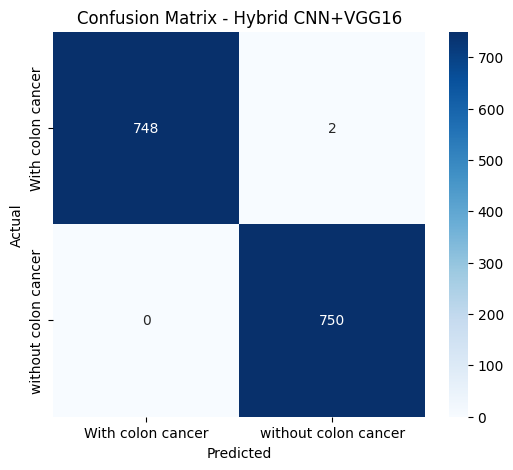

ROC-AUC Score: 1.0000


In [34]:
test_generator.reset()
test_loss, test_acc = hybrid_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

test_generator.reset()
y_pred_prob = hybrid_model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid CNN+VGG16")
plt.savefig('/content/drive/MyDrive/colon/models/hybrid_confusion_matrix.png', dpi=300)
plt.show()

# ROC-AUC
auc = roc_auc_score(y_true, y_pred_prob[:, 1])
print(f"ROC-AUC Score: {auc:.4f}")

In [40]:
def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        try:
            shape = layer.output.shape
            if len(shape) == 4:
                return layer.name
        except AttributeError:
            continue
    return None

last_conv_layer_name = get_last_conv_layer_name(hybrid_model)
print("Last conv layer:", last_conv_layer_name)

Last conv layer: block5_pool


In [41]:
last_conv_layer_name = "block5_conv3"

# Confirm করা যে এই layer আসলেই hybrid_model এ আছে
print(hybrid_model.get_layer(last_conv_layer_name))

<Conv2D name=block5_conv3, built=True>


In [42]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

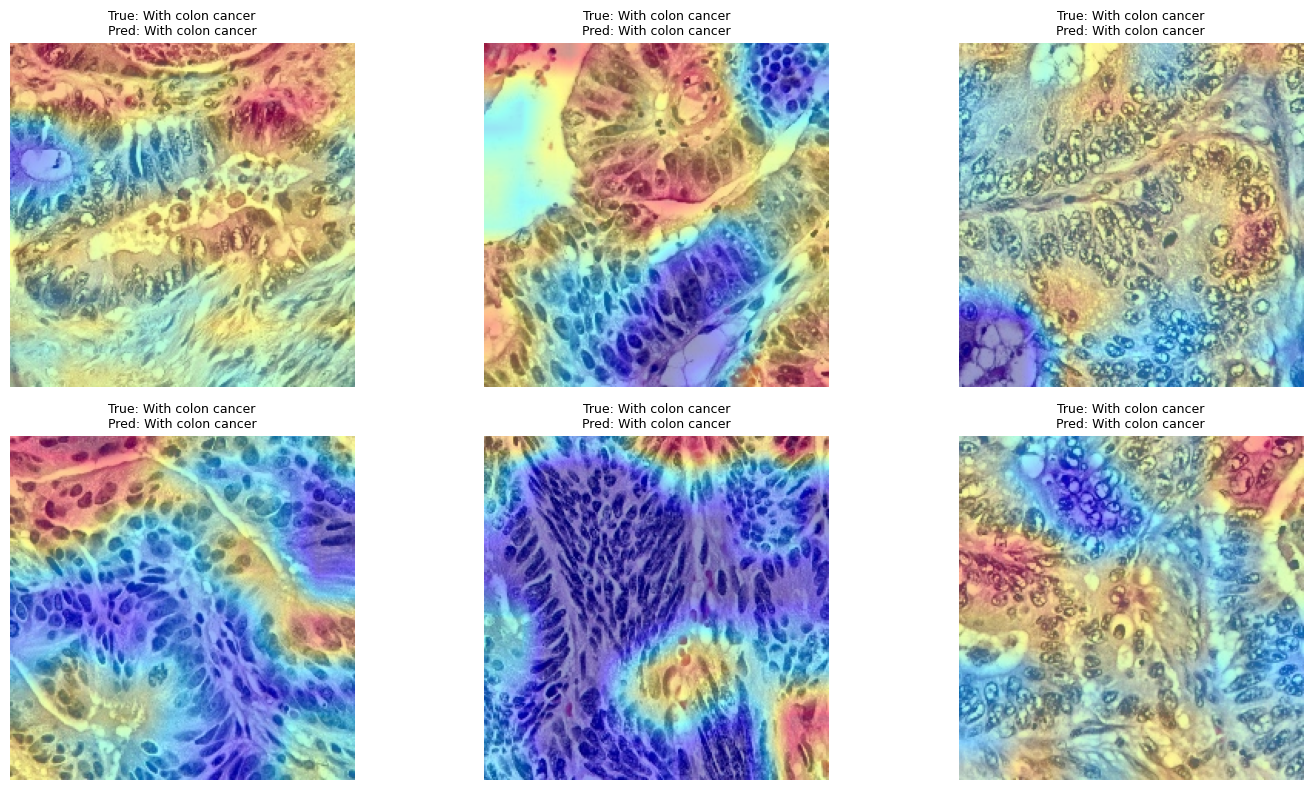

In [43]:
def display_gradcam(img_array, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    original_img = np.uint8(img_array * 255)
    superimposed = cv2.addWeighted(original_img, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed

test_generator.reset()
test_images, test_labels = next(test_generator)

class_labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(15, 8))
for i in range(6):
    img_array = np.expand_dims(test_images[i], axis=0)
    heatmap, pred_class = make_gradcam_heatmap(img_array, hybrid_model, last_conv_layer_name)
    overlay = display_gradcam(test_images[i], heatmap)

    true_class = np.argmax(test_labels[i])

    plt.subplot(2, 3, i + 1)
    plt.imshow(overlay)
    plt.title(f"True: {class_labels[true_class]}\nPred: {class_labels[pred_class]}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/colon/models/gradcam_results.png', dpi=300)
plt.show()